In [ ]:
import sklearn
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
import warnings
import re
from nltk.corpus import stopwords
import nltk
from collections import Counter

In [ ]:
from google.colab import files
files.upload()


Saving author_ru_utf.csv to author_ru_utf.csv


{'author_ru_utf.csv': b'"","document","\xd0\xbd\xd0\xb0","\xd1\x87\xd1\x82\xd0\xbe","\xd0\xb7\xd0\xb0","\xd0\xb8","\xd0\xb2","\xd0\xb8\xd0\xb7","\xd1\x81\xd0\xbe","\xd0\xb0","\xd0\xb2\xd0\xbe","\xd0\xb4\xd0\xbb\xd1\x8f","\xd1\x81","\xd0\xbd\xd0\xbe","\xd0\xba","\xd0\xbf\xd0\xbe","\xd0\xbe\xd1\x82","\xd0\xbf\xd0\xbe\xd0\xb4","\xd0\xb4\xd0\xbe","\xd0\xbf\xd1\x80\xd0\xbe","\xd0\xbe","\xd0\xba\xd0\xbe","\xd0\xbd\xd0\xb0\xd0\xb4","\xd0\xb1\xd0\xb5\xd0\xb7","\xd0\xbf\xd1\x80\xd0\xb8","\xd0\xbe\xd0\xb1","\xd1\x87\xd0\xb5\xd1\x80\xd0\xb5\xd0\xb7","\xd0\xb8\xd0\xb7-\xd0\xb7\xd0\xb0","\xd0\xb8\xd0\xb7-\xd0\xbf\xd0\xbe\xd0\xb4","Author"\r\n"1","\xd0\x93\xd0\xbe\xd0\xb3\xd0\xbe\xd0\xbb\xd1\x8c\xd0\x9d\xd0\x92_\xd0\x92\xd0\xb5\xd1\x87\xd0\xb5\xd1\x80\xd0\xb0\xd0\xa71_1.txt",154,95,42,309,157,40,8,46,10,9,83,22,34,45,17,16,13,13,5,1,6,10,5,4,1,0,0,"\xd0\x93\xd0\xbe\xd0\xb3\xd0\xbe\xd0\xbb\xd1\x8c\xd0\x9d\xd0\x92"\r\n"2","\xd0\x93\xd0\xbe\xd0\xb3\xd0\xbe\xd0\xbb\xd1\x8c\xd0\x9d\xd0\x92_\xd0\x92\xd0\x

In [ ]:
df_au = pd.read_csv("author_ru_utf.csv")
df_au


,Unnamed: 0,document,на,что,за,и,в,из,со,а,...,о,ко,над,без,при,об,через,из-за,из-под,Author
0,1,ГогольНВ_ВечераЧ1_1.txt,154,95,42,309,157,40,8,46,...,5,1,6,10,5,4,1,0,0,ГогольНВ
1,2,ГогольНВ_ВечераЧ1_2.txt,179,158,71,413,233,40,8,53,...,15,2,4,8,11,7,5,1,0,ГогольНВ
2,3,ГогольНВ_ВечераЧ1_3.txt,164,140,52,363,214,29,4,49,...,10,3,5,4,12,4,6,1,1,ГогольНВ
3,4,ГогольНВ_ВечераЧ2_1.txt,172,160,42,370,211,50,7,60,...,9,3,6,12,11,10,4,0,0,ГогольНВ
4,5,ГогольНВ_ВечераЧ2_2.txt,171,129,43,331,183,41,7,67,...,13,3,8,12,6,3,7,5,1,ГогольНВ
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
451,452,ТолстойЛН_Юность_2.txt,188,220,42,434,207,30,12,39,...,24,11,3,15,10,8,8,4,0,ТолстойЛН
452,453,ТолстойЛН_Юность_3.txt,137,180,28,363,175,20,14,40,...,38,8,3,6,4,6,6,2,1,ТолстойЛН
453,454,ТолстойЛН_Юность_4.txt,193,191,30,513,262,29,16,44,...,40,10,13,17,5,8,3,1,0,ТолстойЛН
454,455,ТолстойЛН_Юность_5.txt,144,203,26,439,227,24,11,24,...,34,7,5,7,12,5,5,1,0,ТолстойЛН


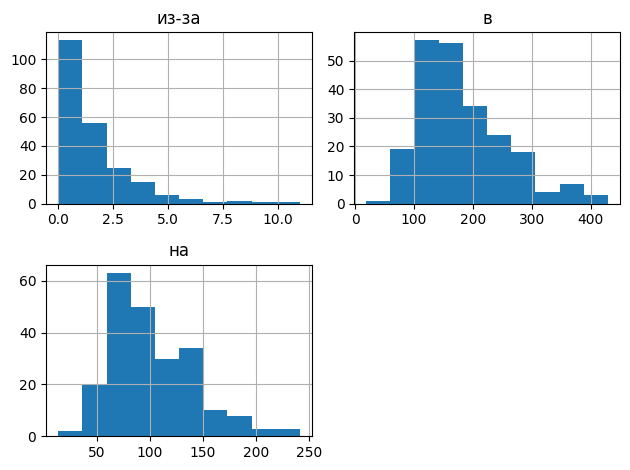

In [ ]:
#auth_2 = df_au[df_au["Author"] == "ТолстойЛН"]
#auth_1 = df_au[df_au["Author"]  == "ГогольНВ"]
#auth_3 = df_au[df_au["Author"]  == "ГончаровИА"]
#auth_4 = df_au[df_au["Author"]  == "ДостоевскийФМ"]
auth_1, auth_2, auth_3, auth_4[["из-за", "в", "на"]].hist(bins=10)
plt.tight_layout()
#df_au[df_au["Author"] == "ТолстойЛН"] & df_au["Author"] == "ГогольНВ"[["из-за", "в", "на"]].hist(bins=20)


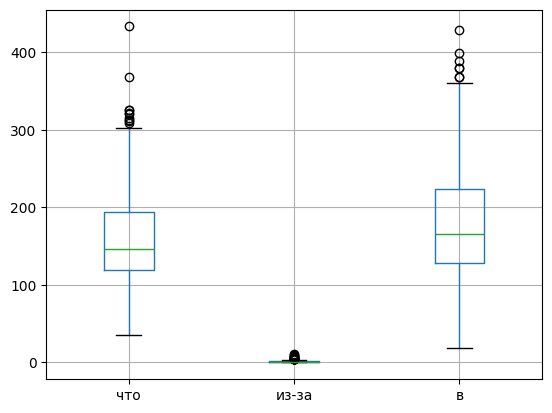

In [ ]:
auth_1, auth_2, auth_3, auth_4[["что", "из-за", "в"]].boxplot();

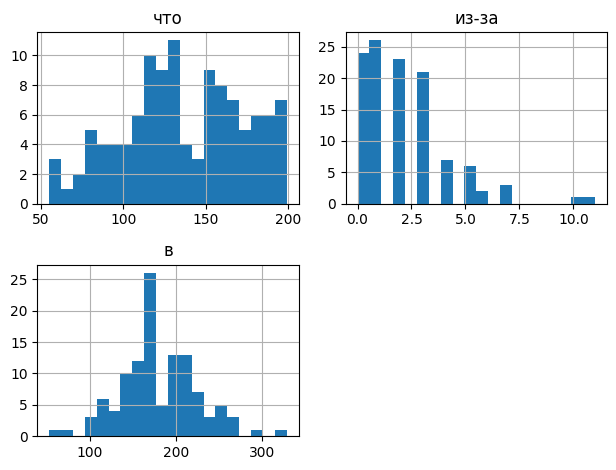

In [ ]:
data = df_au[(df_au["что"] >= 50) & (df_au["что"] <= 200)]
data[data["Author"] == "ТолстойЛН"][["что", "из-за", "в"]].hist(bins=20)
plt.tight_layout()

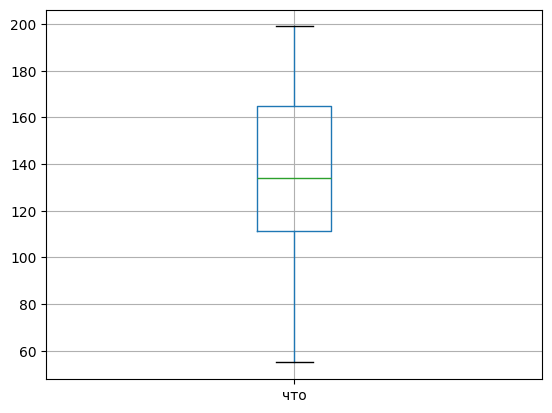

In [ ]:
data[data["Author"] == "ТолстойЛН"][["что"]].boxplot();

In [ ]:
from sklearn.naive_bayes import GaussianNB
gnb = GaussianNB()

train = data[["что", "за", "на"]]
target = data["Author"]

model = gnb.fit(train, target)
predict = model.predict(train)
print(data.shape[0],
     (target == predict).sum() / data.shape[0])

predict

386 0.5155440414507773


array(['ГончаровИА', 'ГогольНВ', 'ГогольНВ', 'ГогольНВ', 'ГогольНВ',
       'ГогольНВ', 'ГогольНВ', 'ГогольНВ', 'ТолстойЛН', 'ГончаровИА',
       'ДостоевскийФМ', 'ДостоевскийФМ', 'ДостоевскийФМ', 'ТолстойЛН',
       'ДостоевскийФМ', 'ТолстойЛН', 'ТолстойЛН', 'ТолстойЛН',
       'ДостоевскийФМ', 'ТолстойЛН', 'ДостоевскийФМ', 'ГогольНВ',
       'ДостоевскийФМ', 'ДостоевскийФМ', 'ДостоевскийФМ', 'ДостоевскийФМ',
       'ДостоевскийФМ', 'ДостоевскийФМ', 'ДостоевскийФМ', 'ДостоевскийФМ',
       'ГогольНВ', 'ТолстойЛН', 'ГогольНВ', 'ДостоевскийФМ', 'ГончаровИА',
       'ГончаровИА', 'ТолстойЛН', 'ГогольНВ', 'ГогольНВ', 'ТолстойЛН',
       'ДостоевскийФМ', 'ДостоевскийФМ', 'ТолстойЛН', 'ДостоевскийФМ',
       'ТолстойЛН', 'ДостоевскийФМ', 'ТолстойЛН', 'ТолстойЛН',
       'ДостоевскийФМ', 'ДостоевскийФМ', 'ТолстойЛН', 'ДостоевскийФМ',
       'ТолстойЛН', 'ГончаровИА', 'ТолстойЛН', 'ГончаровИА',
       'ДостоевскийФМ', 'ДостоевскийФМ', 'ТолстойЛН', 'ДостоевскийФМ',
       'ГончаровИА', 'Достое

In [ ]:
model.predict(train[2:7]), model.predict_proba(train[2:7])

(array(['ГогольНВ', 'ГогольНВ', 'ГогольНВ', 'ГогольНВ', 'ГогольНВ'],
       dtype='<U13'),
 array([[9.80287872e-01, 1.04053429e-02, 5.91717373e-04, 8.71506756e-03],
        [9.62492489e-01, 5.73949134e-04, 1.95745264e-04, 3.67378162e-02],
        [9.66757276e-01, 8.76519566e-07, 1.09071575e-05, 3.32309407e-02],
        [6.12231660e-01, 3.68374758e-01, 1.81465938e-02, 1.24698810e-03],
        [9.77728439e-01, 3.80793935e-04, 6.06488374e-04, 2.12842784e-02]]))

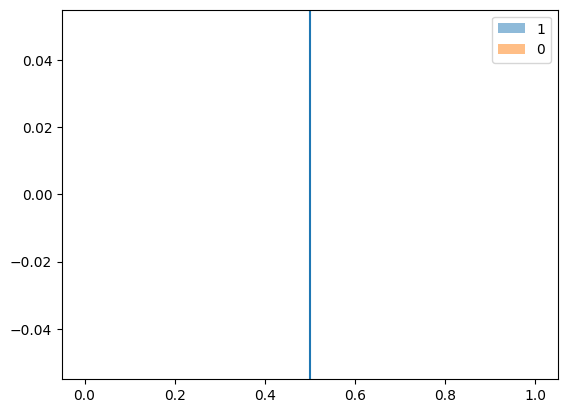

In [ ]:
prob = model.predict_proba(train)[:,1]
plt.hist(prob[target == 1], bins=np.linspace(0, 1, 10), alpha=0.5, label="1");
plt.hist(prob[target == 0], bins=np.linspace(0, 1, 10), alpha=0.5, label="0");
plt.axvline(0.5)
plt.legend();